# Importing the Libraries

In [326]:
import numpy as np
import pandas as pd

In [327]:
df = pd.read_csv('athlete_events.csv')
region_df = pd.read_csv('noc_regions.csv')

In [328]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [329]:
df = df[df["Season"] == "Summer"]

In [330]:
df.shape

(222552, 15)

In [331]:
df = df.merge(region_df, on='NOC', how='left')

In [332]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN


In [333]:
df['region'].unique()

<ArrowStringArray>
[           'China',          'Denmark',      'Netherlands',
          'Finland',           'Norway',          'Romania',
          'Estonia',           'France',          'Morocco',
            'Spain',
 ...
            'Aruba',            'Nauru',          'Vietnam',
           'Bhutan', 'Marshall Islands',         'Kiribati',
            'Tonga',           'Kosovo',      'South Sudan',
          'Lesotho']
Length: 206, dtype: str

In [334]:
df.duplicated().sum()

np.int64(1385)

In [335]:
df.drop_duplicates(inplace=True)

In [336]:
df.duplicated().sum()

np.int64(0)

### Using get_dummies function

In [337]:
pd.get_dummies(df['Medal'], dtype=int)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
...,...,...,...
222547,0,0,0
222548,0,0,0
222549,0,0,0
222550,0,0,0


In [338]:
df = pd.concat([df, pd.get_dummies(df['Medal'], dtype=int)], axis=1)

In [339]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [340]:
df.groupby('NOC').sum()[['Gold', 'Silver', 'Bronze']].sort_values("Gold", ascending=False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,URS,832,635,596
2,GBR,635,729,620
3,GER,592,538,649
4,ITA,518,474,454
...,...,...,...,...
225,WIF,0,0,5
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


In [341]:
medal_tally = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [342]:
medal_tally.shape

(105636, 20)

### Medal Tally

In [343]:
medal_tally = medal_tally.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values("Gold", ascending=False).reset_index()

In [344]:
medal_tally["Total"] = medal_tally["Gold"] + medal_tally["Silver"] + medal_tally["Bronze"]

In [345]:
medal_tally.head()

,region,Gold,Silver,Bronze,Total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777


In [346]:
medal_tally[medal_tally["region"] == "India"]

,region,Gold,Silver,Bronze,Total
47,India,9,7,12,28


In [347]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [348]:
years = df['Year'].unique().tolist()

In [349]:
years

[1992,
 2012,
 1920,
 1900,
 1932,
 1952,
 2000,
 1996,
 1912,
 1924,
 1948,
 2008,
 2016,
 2004,
 1984,
 1968,
 1972,
 1988,
 1936,
 1956,
 1960,
 1928,
 1976,
 1980,
 1964,
 1906,
 1904,
 1908,
 1896]

In [350]:
years.sort()

In [351]:
years

[1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [352]:
years.insert(0, "Overall")

In [353]:
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [354]:
country = df['region'].dropna()

In [355]:
country.shape

(220797,)

In [356]:
country

0               China
1               China
2             Denmark
3             Denmark
4         Netherlands
             ...     
222547      Argentina
222548            USA
222549         Russia
222550         Russia
222551        Belarus
Name: region, Length: 220797, dtype: str

In [357]:
country = country.unique().tolist()

In [358]:
len(country)

205

In [359]:
country.sort()

In [360]:
country

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Guinea',
 'Guin

In [361]:
country.insert(0, "Overall")

In [362]:
country

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [363]:
medal_df = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [364]:
medal_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,1,0,0
222536,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Butterfly,NaN,Poland,NaN,0,0,0
222537,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 200 metres Butterfly,NaN,Poland,NaN,0,0,0


### Filter Function for Medal Tally

In [365]:
def fetch_medal_tally(df, year, country):
    medal_df = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    flag = 0
    if year == "Overall" and country == "Overall":
        temp_df = medal_df
    if year == "Overall" and country != "Overall":
        flag = 1
        temp_df = medal_df[medal_df["region"] == country]
    if year != "Overall" and country == "Overall":
        temp_df = medal_df[medal_df["Year"] == int(year)]
    if year != "Overall" and country != "Overall":
        temp_df = medal_df[(medal_df['Year'] == int(year)) & (medal_df['region'] == country)]

    if flag == 1:
        x = temp_df.groupby('Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values("Year").reset_index()
    else:
        x = temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values("Gold", ascending=False).reset_index()
    x["total"] = x["Gold"] + x["Silver"] + x["Bronze"]

    print(x)
        

In [366]:
fetch_medal_tally(df = medal_df,year = "Overall", country = "India")

    Year  Gold  Silver  Bronze  total
0   1900     0       2       0      2
1   1920     0       0       0      0
2   1924     0       0       0      0
3   1928     1       0       0      1
4   1932     1       0       0      1
5   1936     1       0       0      1
6   1948     1       0       0      1
7   1952     1       0       1      2
8   1956     1       0       0      1
9   1960     0       1       0      1
10  1964     1       0       0      1
11  1968     0       0       1      1
12  1972     0       0       1      1
13  1976     0       0       0      0
14  1980     1       0       0      1
15  1984     0       0       0      0
16  1988     0       0       0      0
17  1992     0       0       0      0
18  1996     0       0       1      1
19  2000     0       0       1      1
20  2004     0       1       0      1
21  2008     1       0       2      3
22  2012     0       2       4      6
23  2016     0       1       1      2


In [367]:
medal_df[medal_df['region'] == "India"]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
436,281,S. Abdul Hamid,M,NaN,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Athletics,Athletics Men's 110 metres Hurdles,NaN,India,NaN,0,0,0
437,281,S. Abdul Hamid,M,NaN,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Athletics,Athletics Men's 400 metres Hurdles,NaN,India,NaN,0,0,0
790,512,Shiny Kurisingal Abraham-Wilson,F,19.0,167.0,53.0,India,IND,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0
791,512,Shiny Kurisingal Abraham-Wilson,F,19.0,167.0,53.0,India,IND,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Women's 4 x 400 metres Relay,NaN,India,NaN,0,0,0
792,512,Shiny Kurisingal Abraham-Wilson,F,23.0,167.0,53.0,India,IND,1988 Summer,1988,Summer,Seoul,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216942,132143,Vikas Krishan Yadav,M,24.0,177.0,69.0,India,IND,2016 Summer,2016,Summer,Rio de Janeiro,Boxing,Boxing Men's Middleweight,NaN,India,NaN,0,0,0
216985,132177,Mohammad Anas Yahiya,M,21.0,177.0,69.0,India,IND,2016 Summer,2016,Summer,Rio de Janeiro,Athletics,Athletics Men's 400 metres,NaN,India,NaN,0,0,0
218411,133029,"Thyadathuvilla Chandrapillai ""T. C."" Yohannan",M,29.0,174.0,62.0,India,IND,1976 Summer,1976,Summer,Montreal,Athletics,Athletics Men's Long Jump,NaN,India,NaN,0,0,0
222416,135480,Geeta Zutshi,F,23.0,167.0,51.0,India,IND,1980 Summer,1980,Summer,Moskva,Athletics,Athletics Women's 800 metres,NaN,India,NaN,0,0,0


In [368]:
medal_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values("Gold", ascending=False).reset_index()

,region,Gold,Silver,Bronze
0,USA,1035,802,708
1,Russia,592,498,487
2,Germany,444,457,491
3,UK,278,317,300
4,France,234,256,287
...,...,...,...,...
200,Vanuatu,0,0,0
201,"Virgin Islands, British",0,0,0
202,"Virgin Islands, US",0,1,0
203,Yemen,0,0,0


### Overall Analysis of the Olympics Data

1. No. of Edition
2. No. of Cities
3. No. of Sports/Events
4. No. of Athletes
5. No. of Participating Nations

#### No.of Edition

In [369]:
df['Year'].unique()

array([1992, 2012, 1920, 1900, 1932, 1952, 2000, 1996, 1912, 1924, 1948,
       2008, 2016, 2004, 1984, 1968, 1972, 1988, 1936, 1956, 1960, 1928,
       1976, 1980, 1964, 1906, 1904, 1908, 1896])

In [370]:
df['Year'].unique().shape[0] - 1

28

#### No. of Cities

In [371]:
df['City'].unique()

<ArrowStringArray>
[     'Barcelona',         'London',      'Antwerpen',          'Paris',
    'Los Angeles',       'Helsinki',         'Sydney',        'Atlanta',
      'Stockholm',        'Beijing', 'Rio de Janeiro',         'Athina',
    'Mexico City',         'Munich',          'Seoul',         'Berlin',
      'Melbourne',           'Roma',      'Amsterdam',       'Montreal',
         'Moskva',          'Tokyo',      'St. Louis']
Length: 23, dtype: str

In [372]:
df['City'].unique().shape[0]

23

#### No. of Sports

In [373]:
df['Sport'].unique()

<ArrowStringArray>
[           'Basketball',                  'Judo',              'Football',
            'Tug-Of-War',             'Athletics',              'Swimming',
             'Badminton',               'Sailing',            'Gymnastics',
      'Art Competitions',              'Handball',         'Weightlifting',
             'Wrestling',            'Water Polo',                'Hockey',
                'Rowing',               'Fencing',         'Equestrianism',
              'Shooting',                'Boxing',             'Taekwondo',
               'Cycling',                'Diving',              'Canoeing',
                'Tennis',     'Modern Pentathlon',                  'Golf',
              'Softball',               'Archery',            'Volleyball',
 'Synchronized Swimming',          'Table Tennis',              'Baseball',
   'Rhythmic Gymnastics',          'Rugby Sevens',          'Trampolining',
      'Beach Volleyball',             'Triathlon',                 'R

In [374]:
df['Sport'].unique().shape[0]

52

#### No. of Events

In [375]:
df['Event'].unique()

<ArrowStringArray>
[                        'Basketball Men's Basketball',
                        'Judo Men's Extra-Lightweight',
                             'Football Men's Football',
                         'Tug-Of-War Men's Tug-Of-War',
                        'Athletics Women's 100 metres',
              'Athletics Women's 4 x 100 metres Relay',
                 'Swimming Men's 400 metres Freestyle',
                             'Badminton Men's Singles',
                          'Sailing Women's Windsurfer',
              'Swimming Men's 200 metres Breaststroke',
 ...
                  'Archery Men's Championnat Du Monde',
                          'Archery Women's Team Round',
             'Wrestling Men's All-Around, Greco-Roman',
                         'Cycling Men's 12-Hours Race',
                 'Swimming Men's 500 metres Freestyle',
     'Weightlifting Men's All-Around Dumbbell Contest',
                'Archery Men's Au Chapelet, 33 metres',
             'Archery Me

In [376]:
df['Event'].unique().shape[0]

651

#### No. of Athletes

In [377]:
df['Name'].unique()

<ArrowStringArray>
[                         'A Dijiang',                           'A Lamusi',
                'Gunnar Nielsen Aaby',               'Edgar Lindenau Aabye',
 'Cornelia "Cor" Aalten (-Strannood)',     'Einar Ferdinand "Einari" Aalto',
                  'Jyri Tapani Aalto',                 'Minna Maarit Aalto',
               'Arvo Ossian Aaltonen',            'Paavo Johannes Aaltonen',
 ...
                       'Dominik ycki',                 'ukasz Tomasz ygado',
                  'Stavroula Zygouri',                      'Frantiek Zyka',
                         'Milan Zyka',          'Olesya Nikolayevna Zykina',
           'Fernando scar Zylberberg',         'James Francis "Jim" Zylker',
       'Aleksandr Viktorovich Zyuzin',             'Olga Igorevna Zyuzkova']
Length: 116122, dtype: str

In [378]:
df['Name'].unique().shape[0]

116122

#### No. of Nations

In [379]:
df['region'].unique()

<ArrowStringArray>
[           'China',          'Denmark',      'Netherlands',
          'Finland',           'Norway',          'Romania',
          'Estonia',           'France',          'Morocco',
            'Spain',
 ...
            'Aruba',            'Nauru',          'Vietnam',
           'Bhutan', 'Marshall Islands',         'Kiribati',
            'Tonga',           'Kosovo',      'South Sudan',
          'Lesotho']
Length: 206, dtype: str

In [380]:
df['region'].unique().shape[0]

206

### Plotting Grapgh for Nations Participated in Olympics

In [381]:
df.drop_duplicates(["Year", "region"])

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198805,121320,Horatio Tertuliano Torrom,M,NaN,NaN,NaN,Argentina,ARG,1908 Summer,1908,Summer,London,Figure Skating,Figure Skating Men's Singles,NaN,Argentina,NaN,0,0,0
203075,123858,Lloyd Oscar Valberg,M,26.0,NaN,NaN,Singapore,SGP,1948 Summer,1948,Summer,London,Athletics,Athletics Men's High Jump,NaN,NaN,NaN,0,0,0
209763,127894,Bruno Julius Wagner,M,25.0,185.0,82.0,Switzerland,SUI,1908 Summer,1908,Summer,London,Athletics,Athletics Men's Hammer Throw,NaN,Switzerland,NaN,0,0,0
215352,131186,Antoni Wiwulski,M,35.0,NaN,NaN,Poland,POL,1912 Summer,1912,Summer,Stockholm,Art Competitions,Art Competitions Mixed Sculpturing,NaN,Poland,NaN,0,0,0


In [382]:
df.drop_duplicates(["Year", "region"])["Year"].value_counts()

Year
2016    204
2012    203
2008    202
2004    200
2000    199
1996    196
1992    168
1988    156
1984    139
1972    120
1968    111
1964     93
1976     91
1960     83
1980     80
1956     71
1952     67
1948     59
1936     49
1932     47
1928     46
1924     45
1900     31
1920     29
1912     29
1908     22
1906     20
1904     14
1896     12
Name: count, dtype: int64

In [383]:
nations_over_time = df.drop_duplicates(["Year", "region"])["Year"].value_counts().reset_index().sort_values("Year")

In [384]:
nations_over_time

,Year,count
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22
24,1912,29
23,1920,29
21,1924,45
20,1928,46
19,1932,47


## Importing plotly library

In [385]:
import plotly.express as px

In [386]:
fig = px.line(nations_over_time, x="Year", y="count")
fig.update_layout(
    yaxis_title="Number of Nations",
    xaxis_title="Year"
)

In [387]:
fig

In [388]:
import matplotlib.pyplot as plt

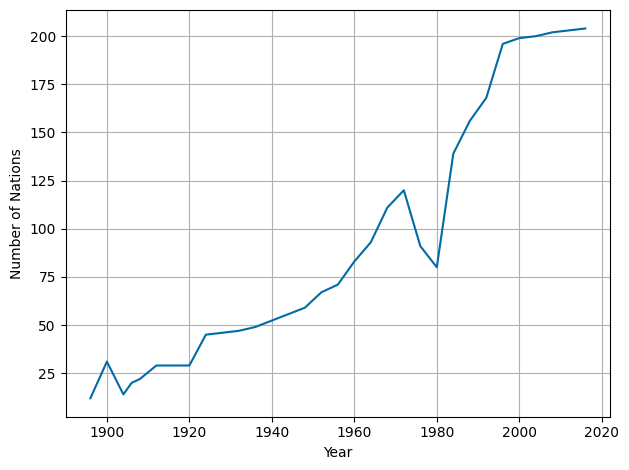

In [389]:
plt.plot(nations_over_time["Year"], nations_over_time["count"])
plt.xlabel("Year")
plt.ylabel("Number of Nations")
plt.tight_layout()
plt.grid()

In [390]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

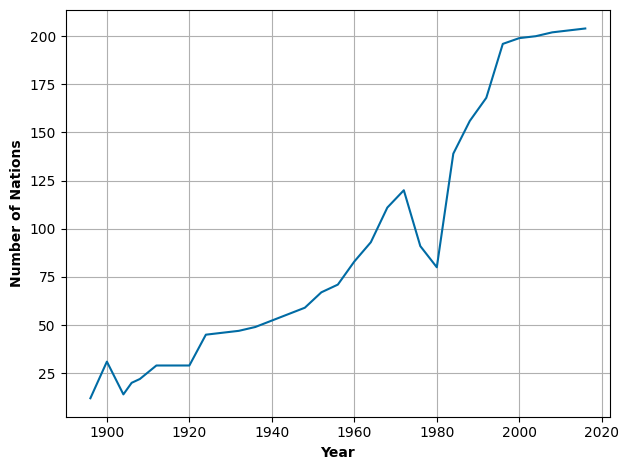

In [391]:
plt.style.use("tableau-colorblind10")
plt.plot(nations_over_time["Year"], nations_over_time["count"])
plt.xlabel("Year", fontweight="bold")  
plt.ylabel("Number of Nations", fontweight="bold")
plt.tight_layout()
plt.grid()

## Plotting Graph for No. of events in each edition of Olympics

In [392]:
events_over_time = df.drop_duplicates(["Year", "Event"])

In [393]:
events_over_time

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160449,97860,Lonce Gaston Quentin,M,40.0,NaN,NaN,France,FRA,1920 Summer,1920,Summer,Antwerpen,Archery,"Archery Men's Target Archery, 28 metres, Indiv...",Silver,France,NaN,0,0,1
161311,98435,Ioannis Raisis,M,NaN,NaN,NaN,Greece,GRE,1906 Summer,1906,Summer,Athina,Fencing,"Fencing Men's Sabre, Masters, Individual",Silver,Greece,NaN,0,0,1
175283,107029,Franz Xaver Schmid,M,27.0,NaN,NaN,Germany,GER,1932 Summer,1932,Summer,Los Angeles,Alpinism,Alpinism Mixed Alpinism,Gold,Germany,NaN,0,1,0
176005,107506,Hermann Schreiber,M,26.0,NaN,NaN,Switzerland,SUI,1936 Summer,1936,Summer,Berlin,Aeronautics,Aeronautics Mixed Aeronautics,Gold,Switzerland,NaN,0,1,0


In [394]:
events_over_time = df.drop_duplicates(["Year", "Event"])["Year"].value_counts().reset_index().sort_values("Year")

In [395]:
events_over_time

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
21,1924,131
22,1928,122
20,1932,131


In [396]:
fig = px.line(events_over_time, x="Year", y="count")
fig.update_layout(
    yaxis_title="Number of Events",
    xaxis_title="Year"
)
fig.show()

## Plotting Graph for No. of athletes in each edition of Olympics

In [397]:
athletes_over_time = df.drop_duplicates(["Year", "Name"])["Year"].value_counts().reset_index().sort_values("Year")

In [398]:
athletes_over_time

,Year,count
28,1896,176
25,1900,1220
27,1904,650
26,1906,841
23,1908,2024
22,1912,2409
21,1920,2675
19,1924,3256
20,1928,3246
24,1932,1922


In [399]:
fig = px.line(athletes_over_time, x="Year", y="count")
fig.update_layout(
    yaxis_title="Number of Athletes",
    xaxis_title="Year"
)

## Plotting graph for No. of events in each sport per edition of Olympics

In [400]:
import seaborn as sns

In [401]:
events_in_each_sports_over_time = df.drop_duplicates(["Year", "Sport", "Event"])

In [402]:
events_in_each_sports_over_time

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160449,97860,Lonce Gaston Quentin,M,40.0,NaN,NaN,France,FRA,1920 Summer,1920,Summer,Antwerpen,Archery,"Archery Men's Target Archery, 28 metres, Indiv...",Silver,France,NaN,0,0,1
161311,98435,Ioannis Raisis,M,NaN,NaN,NaN,Greece,GRE,1906 Summer,1906,Summer,Athina,Fencing,"Fencing Men's Sabre, Masters, Individual",Silver,Greece,NaN,0,0,1
175283,107029,Franz Xaver Schmid,M,27.0,NaN,NaN,Germany,GER,1932 Summer,1932,Summer,Los Angeles,Alpinism,Alpinism Mixed Alpinism,Gold,Germany,NaN,0,1,0
176005,107506,Hermann Schreiber,M,26.0,NaN,NaN,Switzerland,SUI,1936 Summer,1936,Summer,Berlin,Aeronautics,Aeronautics Mixed Aeronautics,Gold,Switzerland,NaN,0,1,0


In [403]:
events_in_each_sports_over_time.pivot_table(
    index="Sport",
    columns="Year",
    values="Event",
    aggfunc="count"
).fillna(0).astype("int")

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Aeronautics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alpinism,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Archery,0,8,6,0,3,0,10,0,0,0,...,2,2,4,4,4,4,4,4,4,4
Art Competitions,0,0,0,0,0,5,5,5,13,13,...,0,0,0,0,0,0,0,0,0,0
Athletics,12,23,24,21,26,30,29,27,27,29,...,38,41,42,43,44,46,46,47,47,47
Badminton,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,5,5,5,5,5,5
Baseball,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,0,0
Basketball,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Basque Pelota,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


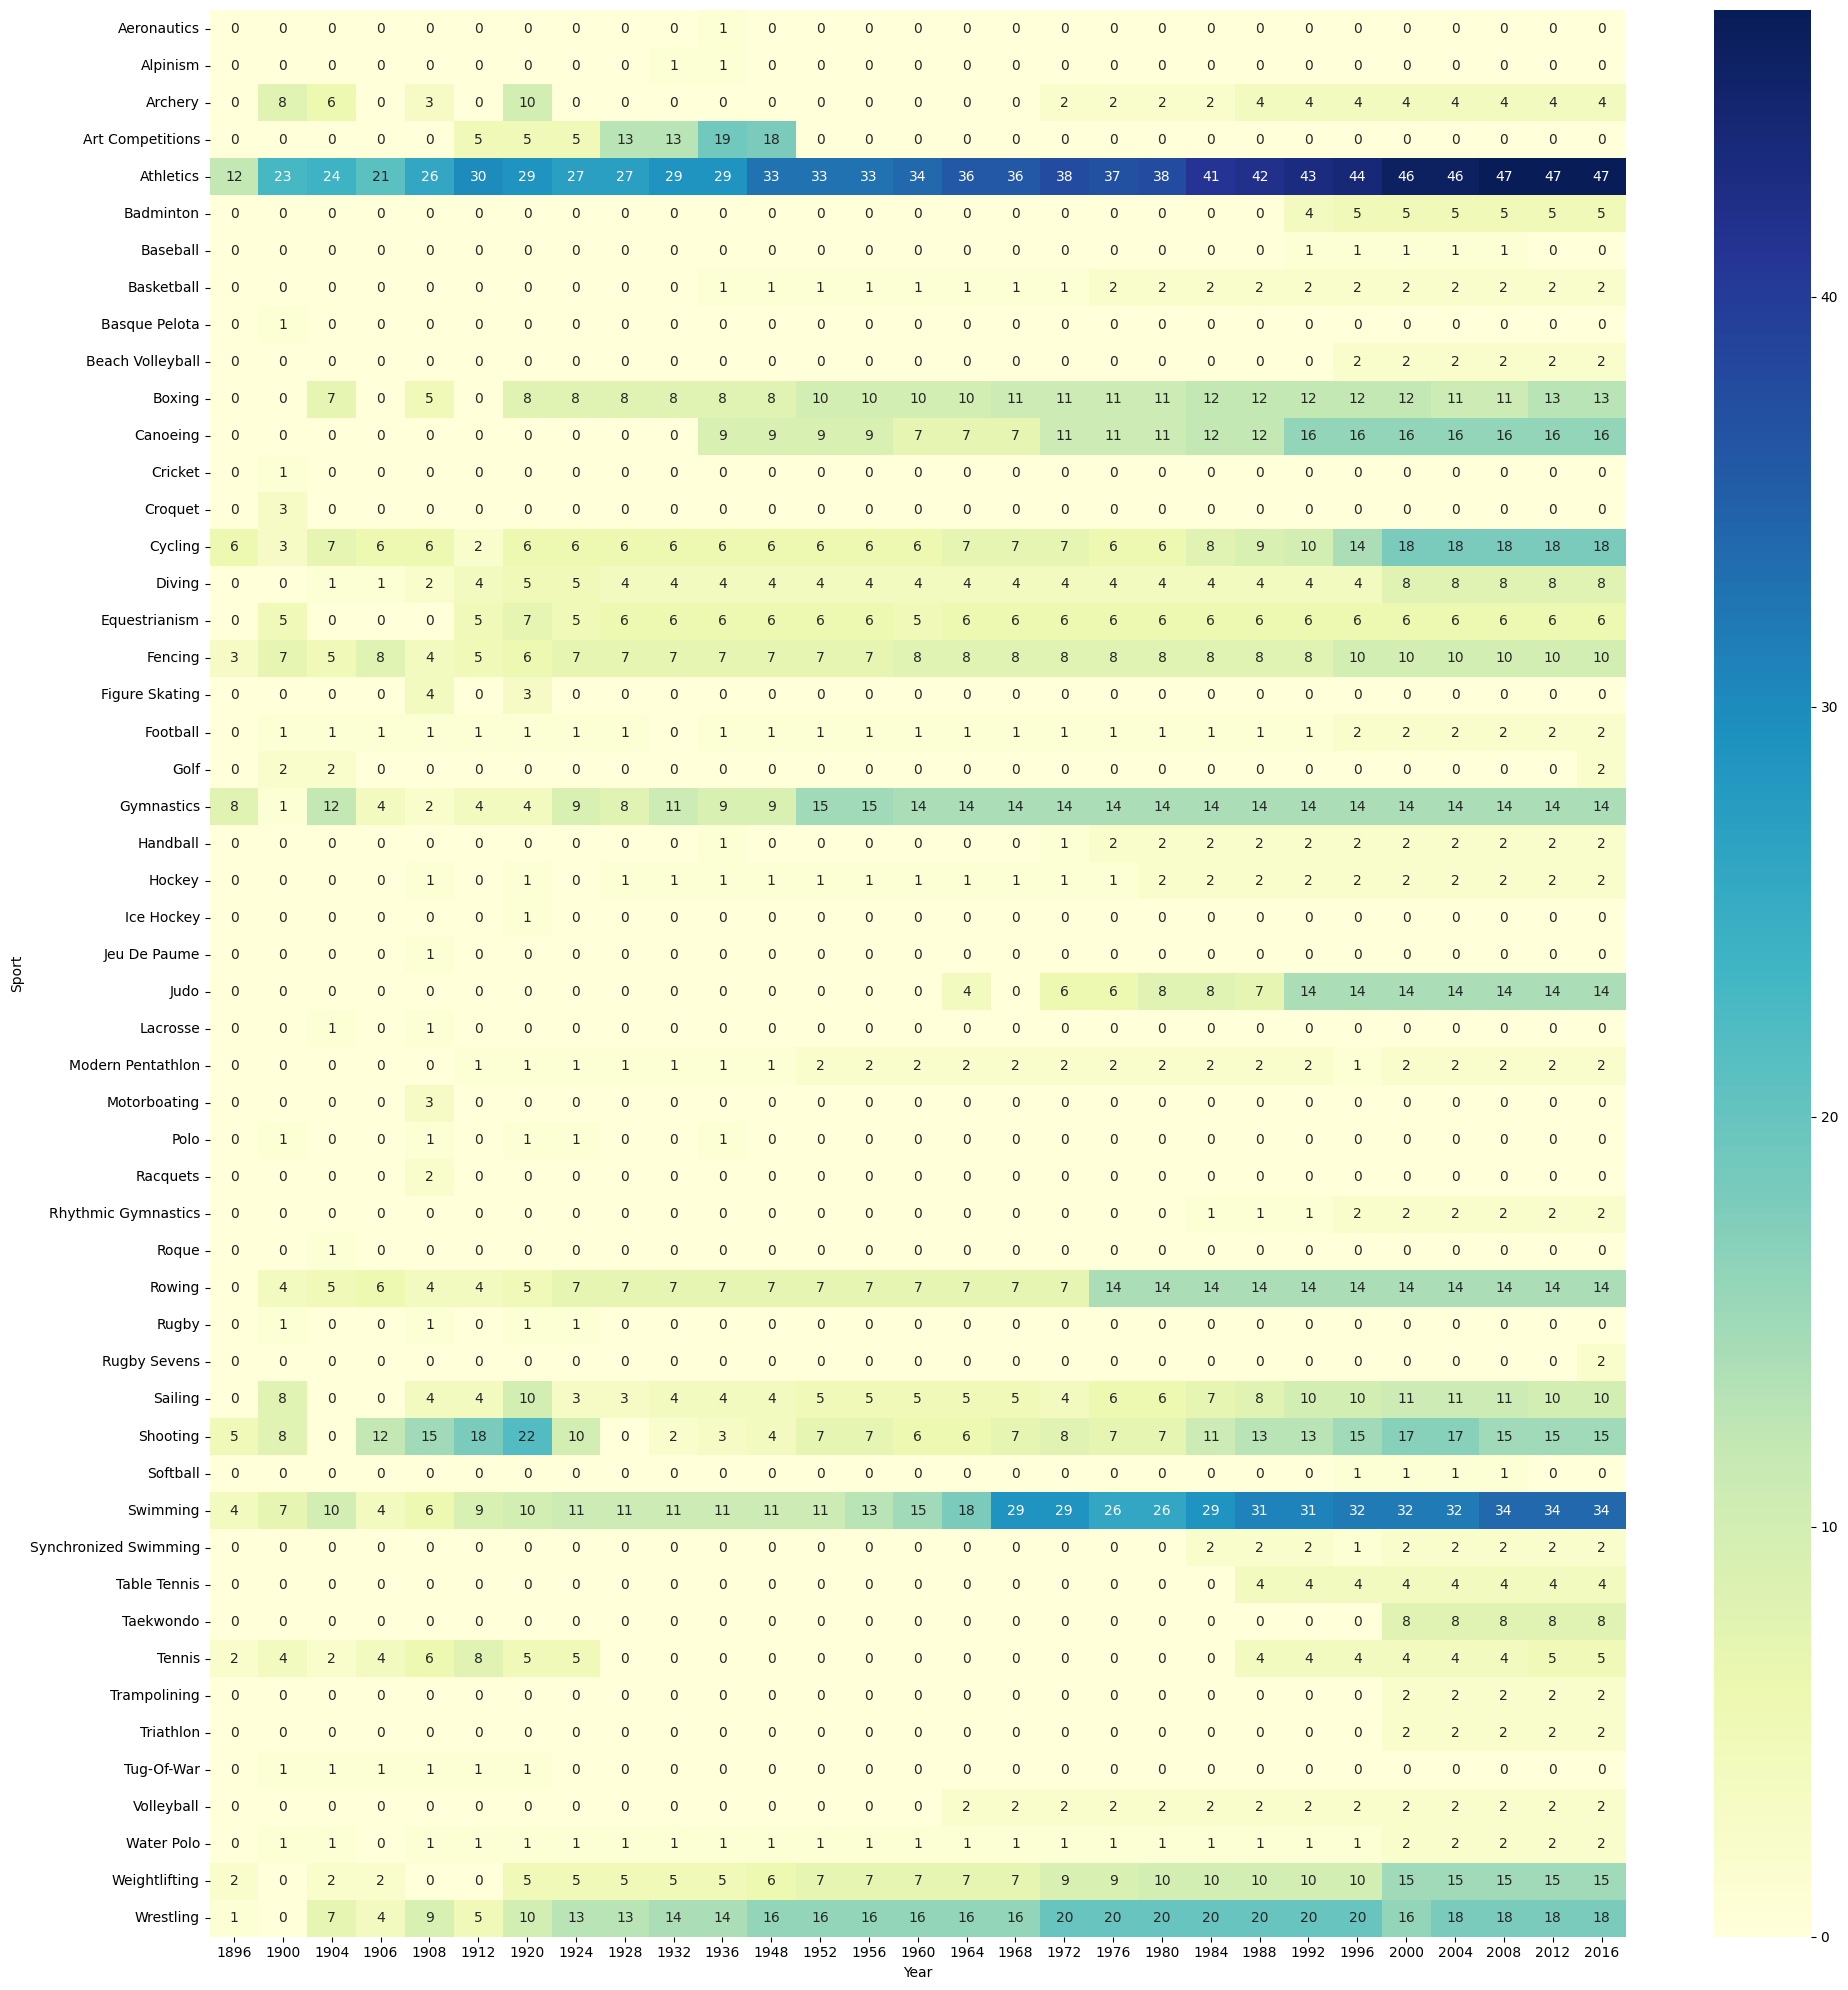

In [404]:
plt.figure(figsize=(20,20))
sns.heatmap(events_in_each_sports_over_time.pivot_table(
    index="Sport",
    columns="Year",
    values="Event",
    aggfunc="count"
).fillna(0).astype("int"), annot=True, cmap="YlGnBu")
plt.tight_layout()

In [405]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222547,135565,Fernando scar Zylberberg,M,27.0,168.0,76.0,Argentina,ARG,2004 Summer,2004,Summer,Athina,Hockey,Hockey Men's Hockey,NaN,Argentina,NaN,0,0,0
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN,0,0,0
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN,0,0,0
222550,135567,Aleksandr Viktorovich Zyuzin,M,28.0,183.0,72.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN,0,0,0


In [406]:
df.dropna(subset=["Medal"])

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
12,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland,NaN,1,0,0
13,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland,NaN,1,0,0
15,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland,NaN,1,0,0
16,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,1,0,0
222532,135554,Bogusaw Zych,M,28.0,182.0,82.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Fencing,"Fencing Men's Foil, Team",Bronze,Poland,NaN,1,0,0
222544,135563,Olesya Nikolayevna Zykina,F,19.0,171.0,64.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Women's 4 x 400 metres Relay,Bronze,Russia,NaN,1,0,0


### Most Successful Athletes

In [407]:
def most_successful_athlete(df, sport):
    temp_df = df.dropna(subset=["Medal"])

    if sport != "Overall":
        temp_df = temp_df[temp_df["Sport"] == sport]

    x = temp_df["Name"].value_counts().reset_index()
    x.columns = ["Name", "Medals"]

    return (
        x.head(10)
        .merge(df, on="Name", how="left")
        [["Name", "Medals", "Sport", "region"]]
        .drop_duplicates("Name")
    )

In [408]:
most_successful_athlete(df, "Overall")

,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Edoardo Mangiarotti,13,Fencing,Italy
87,Takashi Ono,13,Gymnastics,Japan
120,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
144,Natalie Anne Coughlin (-Hall),12,Swimming,USA
156,Birgit Fischer-Schmidt,12,Canoeing,Germany
169,Sawao Kato,12,Gymnastics,Japan
193,Ryan Steven Lochte,12,Swimming,USA


## Country Wise Analysis

1. Country Wise Medal Tally per year(line plot)
2. What country are good at which sport? (Heatmap)
3. Most Successful Athletes(top 10) of each country

#### country Wise Medal Tally per year(line plot)

In [409]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222547,135565,Fernando scar Zylberberg,M,27.0,168.0,76.0,Argentina,ARG,2004 Summer,2004,Summer,Athina,Hockey,Hockey Men's Hockey,NaN,Argentina,NaN,0,0,0
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN,0,0,0
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN,0,0,0
222550,135567,Aleksandr Viktorovich Zyuzin,M,28.0,183.0,72.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN,0,0,0


In [410]:
temp_df = df.dropna(subset=["Medal"])
temp_df = temp_df.drop_duplicates(subset=["Team", "NOC", "Games", "Year", "City", "Sport", "Event", "Medal"])

In [411]:
temp_df 

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
12,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland,NaN,1,0,0
13,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland,NaN,1,0,0
15,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland,NaN,1,0,0
16,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222486,135521,Anton Zwerina,M,23.0,NaN,66.0,Austria,AUT,1924 Summer,1924,Summer,Paris,Weightlifting,Weightlifting Men's Lightweight,Silver,Austria,NaN,0,0,1
222508,135535,Claudia Antoinette Zwiers,F,22.0,181.0,78.0,Netherlands,NED,1996 Summer,1996,Summer,Atlanta,Judo,Judo Women's Middleweight,Bronze,Netherlands,NaN,1,0,0
222526,135553,Galina Ivanovna Zybina (-Fyodorova),F,21.0,168.0,80.0,Soviet Union,URS,1952 Summer,1952,Summer,Helsinki,Athletics,Athletics Women's Shot Put,Gold,Russia,NaN,0,1,0
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1


In [412]:
new_df = temp_df[temp_df['region'] == 'USA']
final_df = new_df.groupby("Year").count()["Medal"].reset_index()

In [413]:
final_df

,Year,Medal
0,1896,19
1,1900,54
2,1904,231
3,1906,23
4,1908,46
5,1912,63
6,1920,95
7,1924,99
8,1928,56
9,1932,110


In [414]:
fig = px.line(final_df, x="Year", y="Medal")
fig.show()

#### which country are good at which sport? (Heatmap)

In [415]:
temp_df = df.dropna(subset=["Medal"])
temp_df = temp_df.drop_duplicates(subset=["Team", "NOC", "Games", "Year", "City", "Sport", "Event", "Medal"])

In [416]:
new_df = temp_df[temp_df['region'] == 'USA']
final_df = new_df.pivot_table(index='Sport', columns='Year', values='Medal', aggfunc='count', fill_value=0)

In [417]:
final_df

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1976,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Archery,0,0,16,0,1,0,0,0,0,0,...,2,2,3,0,2,2,0,0,1,2
Art Competitions,0,0,0,0,0,1,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
Athletics,16,39,65,22,33,41,29,32,25,35,...,22,40,26,30,23,16,25,23,28,32
Baseball,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
Basketball,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Beach Volleyball,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,1,2,2,2,1
Boxing,0,0,18,0,0,0,4,6,3,5,...,7,11,8,3,6,4,2,1,2,3
Canoeing,0,0,0,0,0,0,0,0,0,0,...,0,1,2,3,1,0,1,0,0,0
Cycling,0,1,21,0,0,2,0,0,0,0,...,0,9,1,2,3,2,2,5,4,5


<Axes: xlabel='Year', ylabel='Sport'>

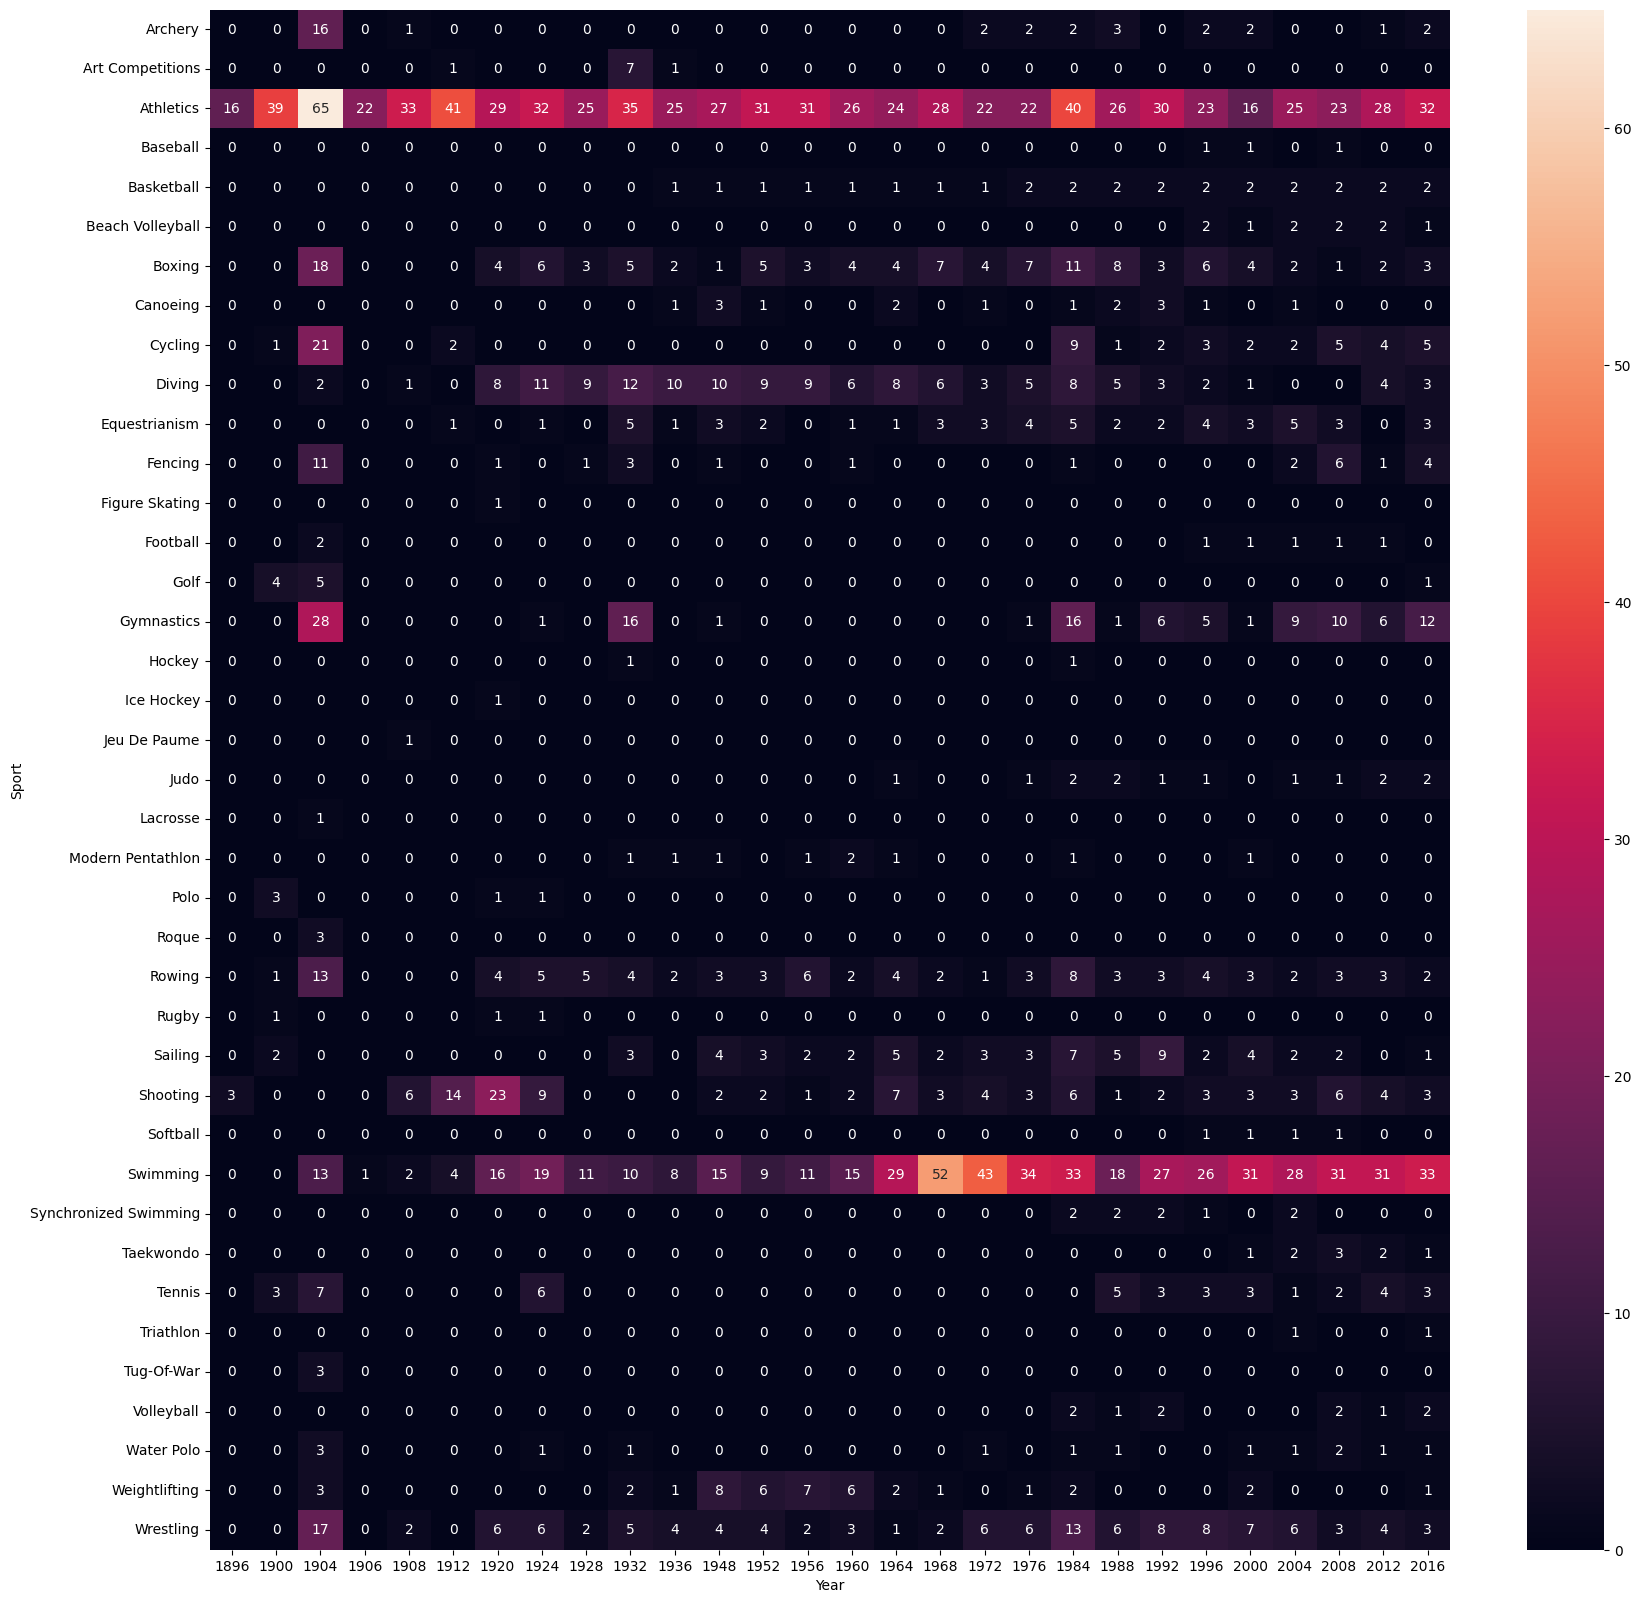

In [418]:
plt.figure(figsize=(20,20))
sns.heatmap(final_df, annot=True)

### most Successful Athletes(top 10) of each country

In [419]:
def most_successful_athlete_of_country(df, country):
    temp_df = df.dropna(subset=["Medal"])

    temp_df = temp_df[temp_df["region"] == country]

    x = temp_df["Name"].value_counts().reset_index()
    x.columns = ["Name", "Medals"]

    return (
        x.head(10)
        .merge(df, on="Name", how="left")
        [["Name", "Medals", "Sport"]]
        .drop_duplicates("Name")
    )

In [420]:
most_successful_athlete_of_country(df, "Canada")

,Name,Medals,Sport
0,"Philip Aron ""Phil"" Edwards",5,Athletics
9,Lesley Allison Thompson-Willie,5,Rowing
17,Victor Davis,4,Swimming
22,Kathleen Joan Heddle,4,Rowing
26,Emilie-Joane Heymans,4,Diving
35,Marnie Elizabeth McBean,4,Rowing
39,"Penelope ""Penny"" Oleksiak",4,Swimming
44,Adam Joseph Van Koeverden,4,Canoeing
50,"Alexander Sheldon ""Alex"" Wilson",4,Athletics
56,"James Allan ""Jimmy"" Ball",3,Athletics


## Athelete Wise Analysis

In [421]:
import plotly.figure_factory as ff

In [422]:
athlete_df = df.drop_duplicates(subset=["Name", "region"])

In [423]:
x1 = athlete_df["Age"].dropna()
x2 = athlete_df[athlete_df["Medal"] == "Gold"]["Age"].dropna()
x3 = athlete_df[athlete_df["Medal"] == "Silver"]["Age"].dropna()
x4 = athlete_df[athlete_df["Medal"] == "Bronze"]["Age"].dropna()

<Axes: ylabel='Frequency'>

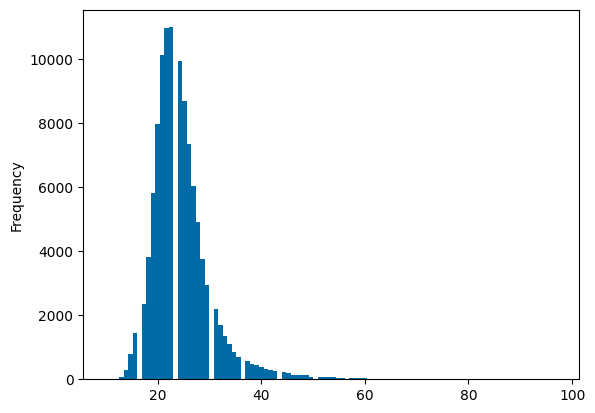

In [424]:
x1.plot(kind="hist", bins = 100)

In [425]:
fig = ff.create_distplot([x1], ["Age Distribution"], show_hist=False, show_rug=False)
fig.show()

In [426]:
fig = ff.create_distplot([x1, x2, x3, x4], ["Age Distribution", "Gold Medalist", "Silver Medalist", "Bronze Medalist"], show_hist=False, show_rug=False)
fig.show()

### Sports wise Age Distribution of Athletes

In [427]:
famous_sports = ['Baseball', "Judo", "Football", "Athletics",
                  "Swimming", "Badminton", "Gymnastics",
                  "Handball", "Weightlifting", "Wrestling",
                  "Water Polo", "Hockey", "Rowing",
                  "Shooting", "Boxing", "Taekwondo", "Cycling", "Diving",
                  "Tennis", "Golf", "Softball", "Archery",
                  "Volleyball", "Table Tennis", "Rugby Sevens",
                  "Beach Volleyball", "Rugby", "Polo", "Ice Hockey"]

In [428]:
x = []
name = []
for sport in famous_sports:
    temp_df = athlete_df[athlete_df["Sport"] == sport]
    x.append(temp_df[temp_df["Medal"] == "Gold"]["Age"].dropna())
    name.append(sport)


In [429]:
x

[648       22.0
 2342      22.0
 2430      27.0
 8278      24.0
 17511     23.0
           ... 
 214068    23.0
 214452    29.0
 218495    22.0
 218720    31.0
 218791    26.0
 Name: Age, Length: 92, dtype: float64,
 5615      22.0
 5765      28.0
 10988     21.0
 13365     21.0
 18689     28.0
           ... 
 217635    24.0
 218588    22.0
 219102    26.0
 221433    23.0
 222463    23.0
 Name: Age, Length: 90, dtype: float64,
 116       22.0
 620       22.0
 1082      20.0
 1886      20.0
 2532      30.0
           ... 
 219679    28.0
 219974    23.0
 220036    23.0
 220386    22.0
 221493    28.0
 Name: Age, Length: 445, dtype: float64,
 551       26.0
 635       22.0
 691       19.0
 1488      26.0
 2604      22.0
           ... 
 219383    20.0
 220130    26.0
 220418    19.0
 221865    23.0
 222526    21.0
 Name: Age, Length: 502, dtype: float64,
 1532      19.0
 1591      19.0
 2156      22.0
 4560      15.0
 5843      21.0
           ... 
 215439    17.0
 215571    17.0
 21858

In [430]:
fig = ff.create_distplot(x, name, show_hist=False, show_rug=False)
fig.show()

### Height vs Weight Distribution of Athletes

In [431]:
athlete_df["Medal"] = athlete_df["Medal"].fillna("No Medal")

In [432]:
athlete_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No Medal,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222544,135563,Olesya Nikolayevna Zykina,F,19.0,171.0,64.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Women's 4 x 400 metres Relay,Bronze,Russia,NaN,1,0,0
222546,135565,Fernando scar Zylberberg,M,23.0,168.0,76.0,Argentina,ARG,2000 Summer,2000,Summer,Sydney,Hockey,Hockey Men's Hockey,No Medal,Argentina,NaN,0,0,0
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,No Medal,USA,NaN,0,0,0
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,No Medal,Russia,NaN,0,0,0


<Axes: xlabel='Weight', ylabel='Height'>

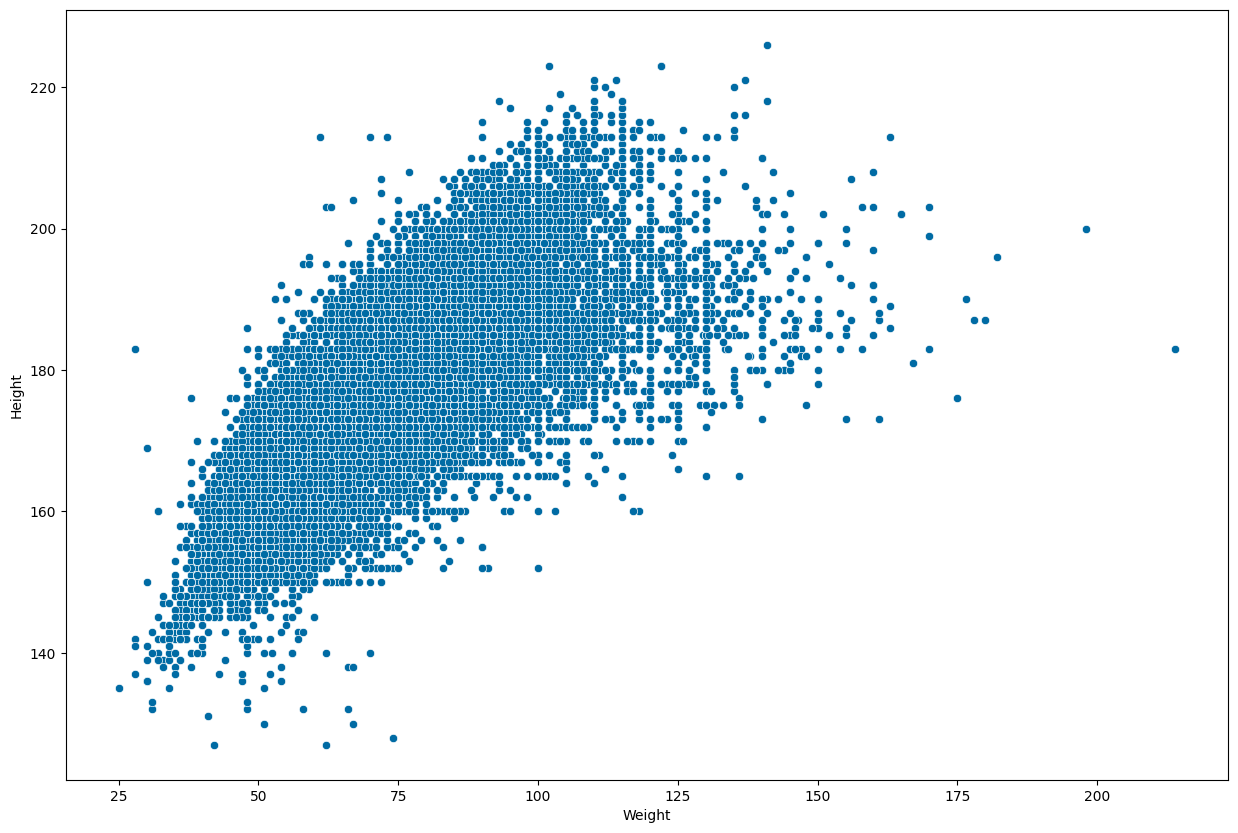

In [437]:
plt.figure(figsize=(15,10))
sns.scatterplot(x=athlete_df["Weight"], y=athlete_df["Height"])

<Axes: xlabel='Weight', ylabel='Height'>

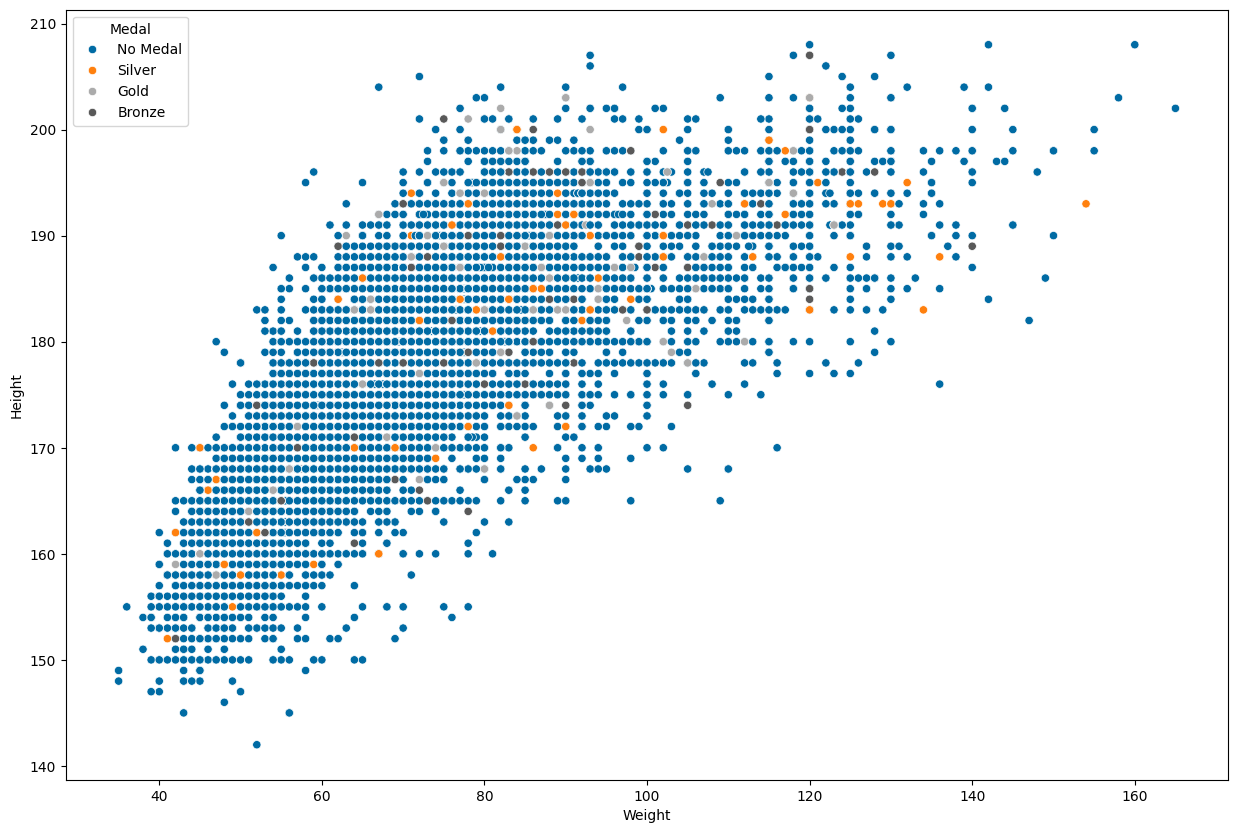

In [438]:
plt.figure(figsize=(15,10))
temp_df = athlete_df[athlete_df["Sport"] == "Athletics"]
sns.scatterplot(x=temp_df["Weight"], y=temp_df["Height"], hue=temp_df["Medal"])

<Axes: xlabel='Weight', ylabel='Height'>

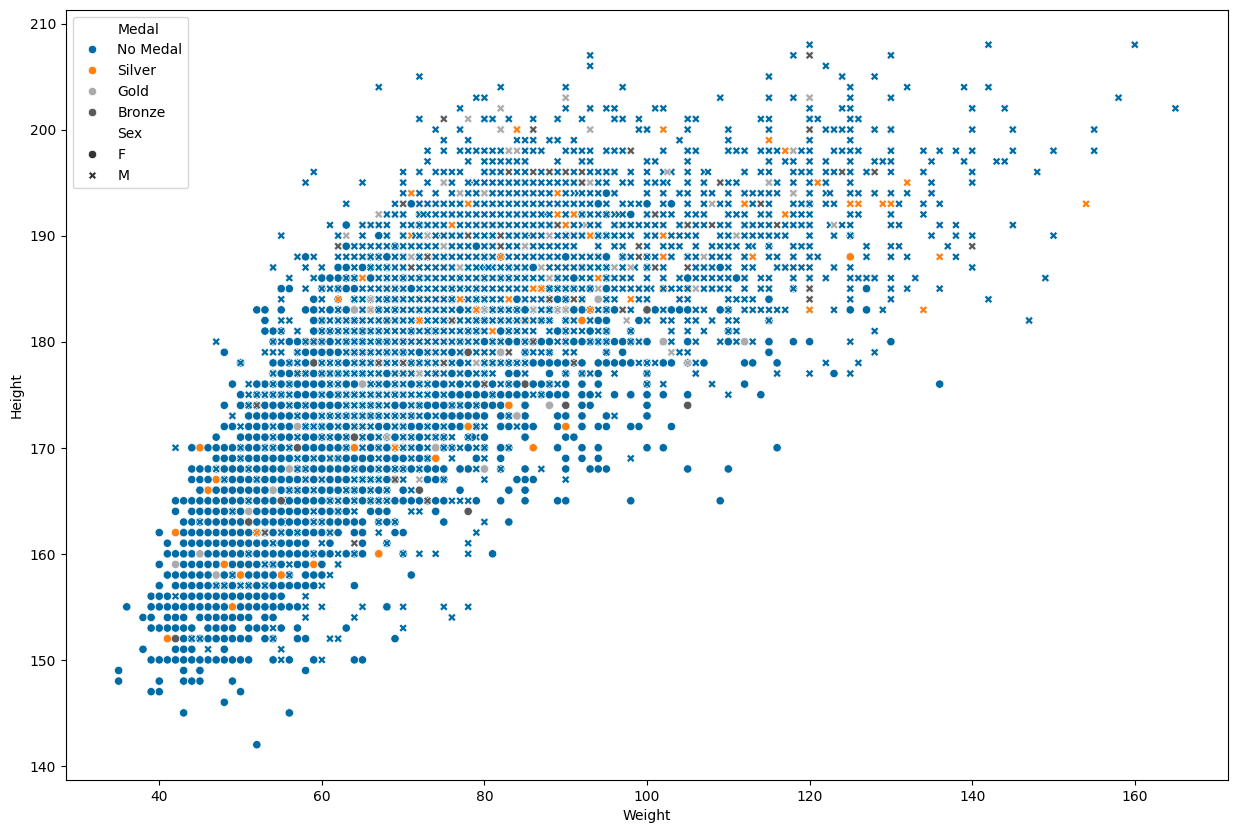

In [443]:
plt.figure(figsize=(15,10))
temp_df = athlete_df[athlete_df["Sport"] == "Athletics"]
sns.scatterplot(x=temp_df["Weight"], y=temp_df["Height"], hue=temp_df["Medal"], style=temp_df["Sex"])

### Male vs Female participation in Olympics over the years

In [455]:
men = athlete_df[athlete_df["Sex"] == "M"].groupby("Year").count()["Name"].reset_index()
women = athlete_df[athlete_df["Sex"] == "F"].groupby("Year").count()["Name"].reset_index()

In [456]:
men

,Year,Name
0,1896,174
1,1900,1181
2,1904,629
3,1906,759
4,1908,1772
5,1912,1978
6,1920,2280
7,1924,2535
8,1928,2342
9,1932,1382


In [460]:
final = men.merge(women, on="Year", how="left")
final.rename(columns={"Name_x": "Male", "Name_y": "Female"}, inplace=True)

In [461]:
final

,Year,Male,Female
0,1896,174,NaN
1,1900,1181,23.0
2,1904,629,6.0
3,1906,759,6.0
4,1908,1772,44.0
5,1912,1978,53.0
6,1920,2280,73.0
7,1924,2535,132.0
8,1928,2342,285.0
9,1932,1382,162.0


In [463]:
final.fillna(0, inplace=True)

,Year,Male,Female
0,1896,174,0.0
1,1900,1181,23.0
2,1904,629,6.0
3,1906,759,6.0
4,1908,1772,44.0
5,1912,1978,53.0
6,1920,2280,73.0
7,1924,2535,132.0
8,1928,2342,285.0
9,1932,1382,162.0


In [465]:
fig = px.line(final, x="Year", y=["Male", "Female"])
fig.show()